In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from DadosAbertosBrasil import ibge
import folium
from branca.colormap import linear
import geopandas as gpd

/Users/juliasbardelatti/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [20]:
df = pd.read_excel("./dados/sisab/paine-indicador.xlsx")
df.columns

Index(['UF', 'IBGE', 'Munícipio', '2022 Q1 (%)', '2022 Q2 (%)', '2022 Q3 (%)',
       '2023 Q1 (%)', '2023 Q2 (%)', '2023 Q3 (%)', '2024 Q1 (%)',
       '2024 Q2 (%)', '2024 Q3 (%)', '2025 Q1 (%)'],
      dtype='object')

In [ ]:
df[].query("2025 Q1 (%)")

0       10
1       18
2       26
3       35
4        9
        ..
5565    46
5566    27
5567    11
5568    34
5569    33
Name: 2025 Q1 (%), Length: 5570, dtype: int64

In [30]:
df['2025 Q1 (%)'] = pd.to_numeric(df['2025 Q1 (%)'], errors='coerce')
def classificar(valor):
    if valor < 20:
        return '< 20%'
    elif valor >= 20 and valor < 40:
        return '≥ 20% e < 40%'
    elif valor >= 40 and valor < 60:
        return '≥ 40% e < 60%'
    elif valor >= 60 and valor < 80:
        return '≥ 60% e < 80%'
    else:
        return '≥ 80% (Meta OMS)'

df['Faixa'] = df['2025 Q1 (%)'].apply(classificar)
resumo = df['Faixa'].value_counts().sort_index().reset_index()
print(resumo)


              Faixa  count
0             < 20%    586
1     ≥ 20% e < 40%   2848
2     ≥ 40% e < 60%   1867
3     ≥ 60% e < 80%    240
4  ≥ 80% (Meta OMS)     29


In [38]:
top_criticos = df.sort_values('2025 Q1 (%)').head(20)
top_criticos['2025 Q1 (%)'] = top_criticos['2025 Q1 (%)'].astype(str) + '%'


In [32]:
ordem = ['< 20%', '≥ 20% e < 40%', '≥ 40% e < 60%','≥ 60% e < 80%' ,'≥ 80% (Meta OMS)']
resumo['Faixa'] = pd.Categorical(resumo['Faixa'], categories=ordem, ordered=True)
resumo['percentual'] = round((resumo['count'] / resumo['count'].sum()) * 100, 4)


In [37]:
resumo

,Faixa,count,percentual
0,< 20%,586,10.5206
1,≥ 20% e < 40%,2848,51.1311
2,≥ 40% e < 60%,1867,33.5189
3,≥ 60% e < 80%,240,4.3088
4,≥ 80% (Meta OMS),29,0.5206


In [36]:
resumo.to_clipboard(decimal=",")

/Users/juliasbardelatti/anaconda3/lib/python3.11/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


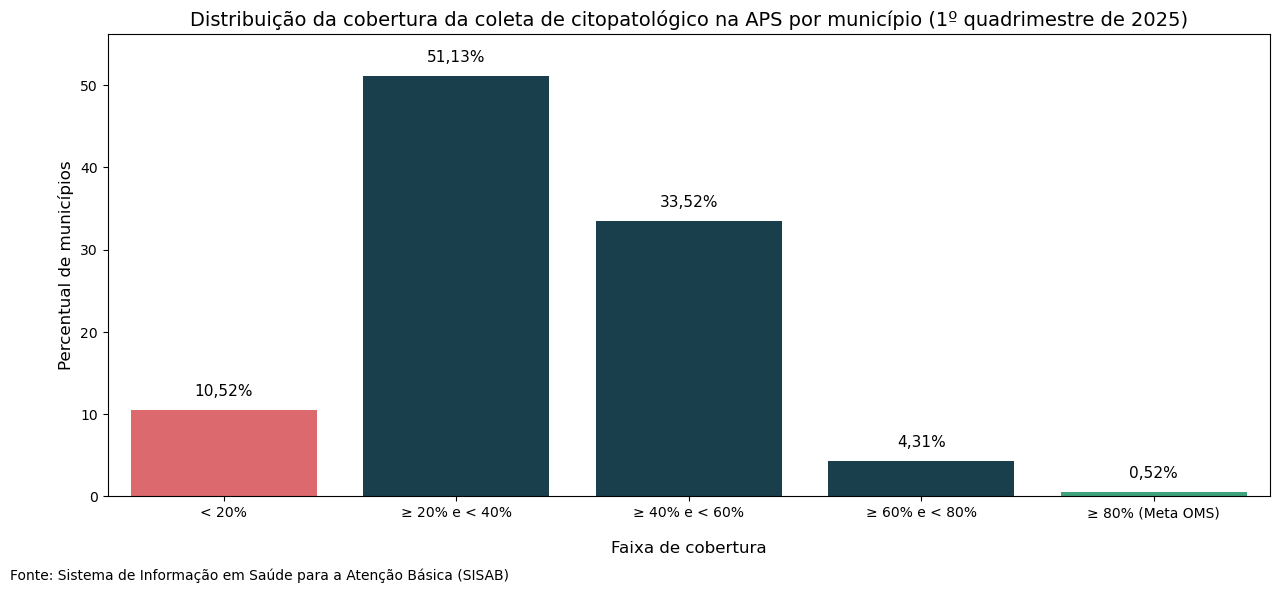

In [35]:
plt.figure(figsize=(15, 6))
ax = sns.barplot(x=resumo['Faixa'], y=resumo['percentual'], palette=["#EF565D", "#114354", "#114354", "#114354", "#2EB280"])
max_count = resumo['percentual'].max()
ax.set_ylim(0, max_count * 1.10)  
for p in ax.patches:
    percentual_formatado = f'{p.get_height():.2f}'.replace('.', ',')
    ax.annotate(f'{percentual_formatado}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                xytext=(0, 8),  
                textcoords='offset points', 
                ha='center', va='bottom', fontsize=11)

plt.title('Distribuição da cobertura da coleta de citopatológico na APS por município (1º quadrimestre de 2025)', fontsize=14)

plt.xlabel('Faixa de cobertura', fontsize=12, labelpad=15)
plt.ylabel('Percentual de municípios', fontsize=12)
plt.xticks()
plt.figtext(0.06, -0.03, 'Fonte: Sistema de Informação em Saúde para a Atenção Básica (SISAB)', horizontalalignment='left', fontsize=10, color='black')
plt.show()

### Municipio

In [41]:
df = pd.read_excel("./dados/sisab/paine-indicador.xlsx")
df = df.rename(columns={
    "IBGE": "codigo_municipio_residencia",
    "2025 Q1 (%)": "indicador_1_2025"
})
df['codigo_municipio_residencia'] = df['codigo_municipio_residencia'].astype(str)

df_regiao = pd.read_csv("./dados/ibge/municipios_regioes.csv")
df_regiao = df_regiao[['codigo_municipio_ibge_novo', 'codigo_municipio_ibge','nome_municipio', 'nome_uf', 'uf', 'regiao', 'cod_uf']]
df_regiao = df_regiao.rename(columns={
    "codigo_municipio_ibge_novo": "codigo_municipio_residencia"
})
df_regiao['codigo_municipio_residencia'] = df_regiao['codigo_municipio_residencia'].astype(str)
df_regiao['codigo_municipio_residencia'] = df_regiao['codigo_municipio_residencia'].str.slice(0, 6)

In [42]:
dados_completos = pd.merge(df, df_regiao, on='codigo_municipio_residencia', how='inner')
len(dados_completos)

5570

In [48]:
dados_completos

,UF,codigo_municipio_residencia,Munícipio,2022 Q1 (%),2022 Q2 (%),2022 Q3 (%),2023 Q1 (%),2023 Q2 (%),2023 Q3 (%),2024 Q1 (%),2024 Q2 (%),2024 Q3 (%),indicador_1_2025,codigo_municipio_ibge,nome_municipio,nome_uf,uf,regiao,cod_uf
0,RO,110004,CACOAL,8,8,7,7,8,9,9,9,9,10,1100049,Cacoal,Rondônia,RO,Norte,11
1,RO,110009,ESPIGÃO D'OESTE,15,15,12,13,14,15,17,18,18,18,1100098,Espigão D'oeste,Rondônia,RO,Norte,11
2,RO,110015,OURO PRETO DO OESTE,12,13,14,17,21,24,27,27,27,26,1100155,Ouro Preto do Oeste,Rondônia,RO,Norte,11
3,RO,110026,RIO CRESPO,27,26,24,27,29,29,32,34,34,35,1100262,Rio Crespo,Rondônia,RO,Norte,11
4,RO,110033,NOVA MAMORÉ,10,10,10,10,11,11,12,11,10,9,1100338,Nova Mamoré,Rondônia,RO,Norte,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5565,GO,522005,SÃO JOÃO DA PARAÚNA,29,30,29,39,40,42,54,50,47,46,5220058,São João da Paraúna,Goiás,GO,Centro-Oeste,52
5566,GO,522070,SÍTIO D'ABADIA,16,16,17,19,21,23,23,24,24,27,5220702,Sítio D'abadia,Goiás,GO,Centro-Oeste,52
5567,GO,522145,TROMBAS,5,4,3,6,6,8,11,11,12,11,5221452,Trombas,Goiás,GO,Centro-Oeste,52
5568,GO,522155,TURVELÂNDIA,18,26,28,29,31,32,33,32,32,34,5221551,Turvelândia,Goiás,GO,Centro-Oeste,52


In [50]:
df_grouped = dados_completos.groupby('nome_uf')['indicador_1_2025'].mean().reset_index()
df_grouped['indicador_1_2025'] = df_grouped['indicador_1_2025'].astype(float)
df_grouped['indicador_1_2025'] = df_grouped['indicador_1_2025']
df_grouped.to_clipboard(decimal=",")


In [52]:
df_grouped.sort_values("indicador_1_2025", ascending=True)


,nome_uf,indicador_1_2025
6,Distrito Federal,18.000000
21,Rondônia,21.346154
20,Rio de Janeiro,26.184783
15,Pará,26.479167
8,Goiás,28.321138
0,Acre,29.090909
11,Mato Grosso do Sul,31.000000
24,Sergipe,32.160000
25,São Paulo,33.238760
9,Maranhão,33.253456


In [47]:
geojson_path = ibge.malha(
    nivel = 'paises',
    localidade = 'BR',
    divisoes = 'uf',
    formato = 'geojson'
)
mapa = folium.Map(location=[-14.2350, -51.9253], zoom_start=4, tiles=None)
colormap = linear.YlOrRd_09.scale(0, 100)  # Define a escala fixa de 0 a 100
colormap.caption = 'df_grouped de casos com tratamento após 60 dias (%)'
colormap.caption = 'Cobertura média de coleta citopatológica (%)'
folium.Choropleth(
    geo_data=geojson_path,
    data=df_grouped,
    columns=["cod_uf", "indicador_1_2025"],
    key_on="feature.properties.codarea",
    fill_color="Blues",
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name="Cobertura média de coleta citopatológica (%)",
    nan_fill_color="white",
    nan_fill_opacity=0.3
).add_to(mapa)

if isinstance(geojson_path, dict):
    gdf = gpd.GeoDataFrame.from_features(geojson_path["features"])
else:
    gdf = gpd.read_file(geojson_path)  

gdf["codarea"] = gdf["codarea"].astype(int)

for _, row in gdf.iterrows():
    estado_codigo = row["codarea"]
    centroide = row.geometry.centroid  
    tempo_tratamento = df_grouped.loc[df_grouped["cod_uf"] == estado_codigo, "indicador_1_2025"]
    if not tempo_tratamento.empty:
        valor = f"{round(tempo_tratamento.values[0], 1)}%" 
        folium.Marker(
            location=[centroide.y, centroide.x], 
            icon=folium.DivIcon(html=f"""
                <div style="
                    font-size: 12px; 
                    font-weight: bold; 
                    color: black; 
                    background: rgba(255,255,255,0.85);
                    padding: 4px 6px;
                    border-radius: 5px;
                    text-align: center;
                    display: inline-block;
                    box-shadow: 2px 2px 5px rgba(0,0,0,0.3);
                    border: 1px solid rgba(0,0,0,0.2);
                ">
                    {valor}
                </div>""")
        ).add_to(mapa)
mapa.get_root().html.add_child(folium.Element("""
    <style>
        html, body {
            background-color: white !important;
            height: 100%;
            margin: 0;
        }
        .folium-map { background: white; }
        #map { height: 100%; }
    </style>
"""))
mapa.save("teste.html")
